### Efficient transformers library for Cloud AI 100

Copyright (c) Qualcomm Technologies, Inc. and/or its subsidiaries.<br>
SPDX-License-Identifier: BSD-3-Clause-Clear

Efficient-transformers library provides reimplemented blocks of LLMs which are used to make the models functional and highly performant on Qualcomm Cloud AI 100.

Users only need to specify the model card name from HuggingFace, and the library will handle the transformation to its efficient implementation for Cloud AI 100.

Visit https://quic.github.io/efficient-transformers/source/introduction.html and https://github.com/quic/efficient-transformers for more details about the library.

Below are the high-level steps for running any model using the efficient transformers library:

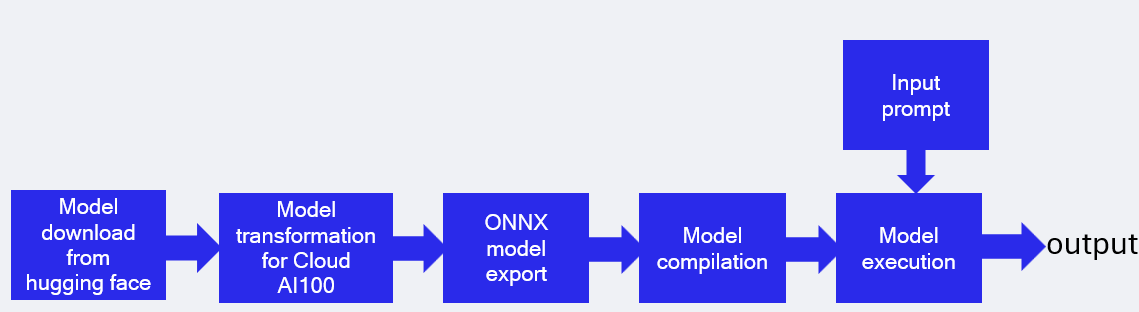

#### Verify installation

In [2]:
# verify successful installation
import QEfficient; print(QEfficient.__version__)

0.0.1.dev0


#### Login with hugging face token.


In [3]:
from huggingface_hub import login

# add your hugging face token here to access the model
token = "YOUR_HF_TOKEN"

login(token)

#### Import libraries

Please refer https://quic.github.io/efficient-transformers/source/hl_api.html for detailed explanation of High Level Python API.

In [4]:
from QEfficient import QEFFAutoModelForCausalLM as AutoModelForCausalLM
from transformers import AutoTokenizer

#### Model storage path 

By default, the library exported models and Qaic Program Container (QPC) files are stored in ~/.cache/qeff_cache. You can customize this storage path using the following environment variables:

QEFF_HOME: If this variable is set, its path will be used for storing models and QPC files.

XDG_CACHE_HOME: If QEFF_HOME is not set but XDG_CACHE_HOME is provided, this path will be used instead. Note that setting XDG_CACHE_HOME will reroute the entire ~/.cache directory to the specified folder, including HF models.

Default: If neither QEFF_HOME nor XDG_CACHE_HOME are set, the default path ~/.cache/qeff_cache will be used.

In [5]:
# set environment variable for model storage path 
!export XDG_CACHE_HOME="/local/mnt/workspace/HF/"

#### Model loading from hugging face  
Download the model from Hugging Face and perform the necessary transformations for Cloud AI 100 devices. If the model is already available, it will not be redownloaded.

In [6]:
# Model Card name for model to be onboarded (This is HF Model Card name)
modelName = "meta-llama/Llama-3.1-8B-Instruct" # change model name here to try with different models
qeff_model = AutoModelForCausalLM.from_pretrained(modelName)
tokenizer = AutoTokenizer.from_pretrained(modelName)

Loading checkpoint shards: 100%|████████████████████████████████████████████████████| 4/4 [00:03<00:00,  1.23it/s]


#### ONNX model export 

In [7]:
# Export the model to ONNX framework.
# This will generate ONNX Model.

qeff_model.export()

PosixPath('/local/mnt/workspace/HF/qeff_models/LlamaForCausalLM-bc130d9421f7238e/LlamaForCausalLM.onnx')

#### Check the status of cloud AI 100 cards

In [ ]:
!/opt/qti-aic/tools/qaic-util -q

#### Model compilation

This method compiles the exported ONNX model using the Cloud AI 100 App SDK compiler binary found at "/opt/qti-aic/exec/qaic-exec".<br>
The generated file is known as the Qaic Program Container (QPC), optimized for Cloud AI 100 devices.<br>

Refer https://quic.github.io/efficient-transformers/source/hl_api.html#QEfficient.transformers.models.modeling_auto.QEFFAutoModelForCausalLM.compile for more details about API.

Refer https://quic.github.io/cloud-ai-sdk-pages/latest/Getting-Started/Features/model_sharding/ for more details about tensor slicing.

In [9]:
#Number of cores to be used by compiled model. Please refer to the number of cores available on the AIC 100 card.
#Use 16 for AI100Pro,AI100Ultra.
#Use 14 for AI100Std.
#Use 8 for AI080Ultra
numCores = 16

#Number of devices/QIDs to be used by compiled model.
#If this integer value is greater than one, tensor slicing shall be enabled.
num_devices = 4

#Batch size
batchSize = 1

#set True to use mxfp6 compression for weights.
use_mxfp6 = True

#set True to use mxint8 compression for KV cache
use_mxint8 = True

#Enables DFS with default memory size
enable_DFS = True

# Context length
ctx_len = 4096

# length of the Prefill prompt 
prefill_seq_len = 128

#Continuous batching batch size
full_batch_size = 1

qeff_model.compile(
    num_cores=numCores,
    ctx_len=ctx_len,
    prefill_seq_len=prefill_seq_len,
    batch_size=batchSize,
    mxfp6_matmul=use_mxfp6,
    mxint8_kv_cache=use_mxint8,
    full_batch_size=full_batch_size,
    aic_enable_depth_first=enable_DFS,
    num_devices=num_devices
)

PosixPath('/local/mnt/workspace/HF/qeff_models/LlamaForCausalLM-bc130d9421f7238e/qpc-2d0b28bbca7aef0b/qpc')

#### Model execution 

This method produces output by executing the compiled QPC on Cloud AI 100 cards.<br>

Refer https://quic.github.io/efficient-transformers/source/hl_api.html#QEfficient.transformers.models.modeling_auto.QEFFAutoModelForCausalLM.generate for more details about API.


In [10]:
# provide prompt to be given to the model
prompt = ["My name is"]

#If model is compiled with num_devices>1 then tensor slicing shall be enabled(https://quic.github.io/cloud-ai-sdk-pages/latest/Getting-Started/Features/model_sharding/).
#Provide QIDs in a list to run the model across SoCs/Cards connected to the same PCIe switch which helps imporve throughput/latency/batch-size support.
#For example, one cloud AI 100 ultra card has 4 SOCs, each assigned a unique QID which can be passed as [0,1,2,3].
#Two cloud AI 100 ultra card has total 8 SOCs, each assigned a unique QID which can be passed as [0,1,2,3,4,5,6,7]. 
deviceID=[0,1,2,3]

# generation length
generation_len = 256

#generate the output
qeff_model.generate(tokenizer=tokenizer,prompts=prompt,device_id=deviceID,generation_len=generation_len)


Prompt : My name is
Completion : Emily, and I am a 25-year-old freelance writer and editor living in the Pacific Northwest. I have a passion for storytelling, and I love helping others tell their stories through writing and editing.
I have a degree in English from the University of Washington, and I have been writing and editing for over five years. I have worked with a variety of clients, from small businesses to non-profit organizations, and I have a proven track record of delivering high-quality content on time and within budget.
In addition to my work as a writer and editor, I am also a passionate advocate for social justice and environmental sustainability. I believe that writing and storytelling have the power to inspire and educate, and I am committed to using my skills to make a positive impact in the world.
When I'm not working, you can find me hiking in the mountains, practicing yoga, or trying out a new recipe in the kitchen. I am a bit of a bookworm, and I love getting los

Average Prefill time a.k.a TTFT is= 0.06        
Decode token/sec is= 49.28        
Total token/sec is= 48.71        
Total (E2E) inference time is= 5.24

#### Models with PEFT adapters

Refer https://quic.github.io/efficient-transformers/source/hl_api.html#qeffautopeftmodelforcausallm for more details.

##### import library

In [11]:
from QEfficient import QEffAutoPeftModelForCausalLM
from transformers import AutoTokenizer, TextStreamer

##### Tokenizer for Base model

In [12]:
# model card name of the base model 
base_model_name = "mistralai/Mistral-7B-v0.1"
tokenizer = AutoTokenizer.from_pretrained(base_model_name)
streamer = TextStreamer(tokenizer)

In [13]:
#Adapter model ID from huggingface hub
model_id="predibase/magicoder"

#Adapter name to be used to set this as current adapter
adapter_name="magicoder"

In [14]:
# Model download from hugging face
model = QEffAutoPeftModelForCausalLM.from_pretrained(model_id,adapter_name,attn_implementation="eager")

Loading checkpoint shards: 100%|████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.26s/it]


##### ONNX model export

Refer https://quic.github.io/efficient-transformers/source/hl_api.html#QEfficient.peft.auto.QEffAutoPeftModelForCausalLM.compile for more details about API.

In [15]:
# model export to onnx
model.export()

PosixPath('/local/mnt/workspace/HF/qeff_models/MistralForCausalLM-lora-2d26f2935099f4ba/MistralForCausalLM-lora.onnx')

##### Model compilation

Refer https://quic.github.io/efficient-transformers/source/hl_api.html#QEfficient.peft.auto.QEffAutoPeftModelForCausalLM.compile for more details about API.

Refer https://quic.github.io/cloud-ai-sdk-pages/latest/Getting-Started/Features/model_sharding/ for more details about tensor slicing.

In [16]:
#Number of cores to be used by compiled model. Please refer to the number of cores available on the AIC 100 card.
#Use 16 for AI100Pro,AI100Ultra.
#Use 14 for AI100Std.
#Use 8 for AI080Ultra
numCores = 16

#Number of devices/QIDs to be used by compiled model.
#If this integer value is greater than one, tensor slicing shall be enabled.
num_devices = 1

#Batch size
batchSize = 1

#set True to use mxfp6 compression for weights.
use_mxfp6 = True

#set True to use mxint8 compression for KV cache
use_mxint8 = True

#Enables DFS with default memory size
enable_DFS = True

# Context length
ctx_len = 1024

#The length of the Prefill prompt 
prefill_seq_len = 32

model.compile(
    num_cores=numCores,
    ctx_len=ctx_len,
    prefill_seq_len=prefill_seq_len,
    batch_size=batchSize,
    mxfp6_matmul=use_mxfp6,
    mxint8_kv_cache=use_mxint8,
    aic_enable_depth_first=enable_DFS,
    num_devices=num_devices
)

PosixPath('/local/mnt/workspace/HF/qeff_models/MistralForCausalLM-lora-2d26f2935099f4ba/qpc-913a3116df3975ca/qpc')

##### Set adapter

In [17]:
# set adapter
model.set_adapter("magicoder")

# verify active adapter
print(model.active_adapter)

magicoder


##### Model execution

In [18]:
#If model is compiled with num_devices>1 then tensor slicing shall be enabled(https://quic.github.io/cloud-ai-sdk-pages/latest/Getting-Started/Features/model_sharding/).
#Provide QIDs in a list to run the model across SoCs/Cards connected to the same PCIe switch which helps imporve throughput/latency/batch-size support.
#For example, one cloud AI 100 ultra card has 4 SOCs, each assigned a unique QID which can be passed as [0,1,2,3].
#Two cloud AI 100 ultra card has total 8 SOCs, each assigned a unique QID which can be passed as [0,1,2,3,4,5,6,7]. 
deviceID=[0,1,2,3]

In [19]:
prompt = """Below is a programming problem, paired with a language in which the code should be written.
### Problem: You are given two arrays, A and B, each of length n. You need to perform a convolution operation on these arrays and output the resulting array.
### Language: python
"""

In [20]:
inputs = tokenizer(prompt, return_tensors="pt")
text = model.generate(**inputs, streamer=streamer, max_new_tokens=1024,device_ids=deviceID)

Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


<s> Below is a programming problem, paired with a language in which the code should be written.
### Problem: You are given two arrays, A and B, each of length n. You need to perform a convolution operation on these arrays and output the resulting array.
### Language: python


/local/mnt/workspace/meghpate/notebook_cleanup/2024/qeff_env/lib/python3.10/site-packages/QEfficient/peft/auto.py:351: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  if stopping_criteria(torch.from_numpy(inputs["input_ids"]), torch.from_numpy(outputs["logits"])).all():


```python
def convolution(A, B):
   n = len(A)
   C = [0] * (n + 1)
   for i in range(n):
       for j in range(n):
           C[i + j] += A[i] * B[j]
   return C[1:]
```

The `convolution` function takes two arrays `A` and `B` as input and performs the convolution operation on them. It then returns the resulting array `C`. The time complexity of this algorithm is O(n^2).</s>


In [21]:
prompt = """Below is a programming problem, paired with a language in which the code should be written.
### Problem: You are given two arrays, A and B, each of length n. You need to perform a convolution operation on these arrays and output the resulting array.
### Language: cpp
"""

In [22]:
inputs = tokenizer(prompt, return_tensors="pt")
text = model.generate(**inputs, streamer=streamer, max_new_tokens=1024,device_ids=deviceID)

Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


<s> Below is a programming problem, paired with a language in which the code should be written.
### Problem: You are given two arrays, A and B, each of length n. You need to perform a convolution operation on these arrays and output the resulting array.
### Language: cpp
```cpp
#include <iostream>
#include <vector>

using namespace std;

vector<int> convolution(vector<int> A, vector<int> B) {
   int n = A.size();
   vector<int> C(n);

   for (int i = 0; i < n; i++) {
       for (int j = 0; j < n; j++) {
           C[i] += A[i] * B[j];
       }
   }

   return C;
}

int main() {
   vector<int> A = {1, 2, 3};
   vector<int> B = {4, 5, 6};

   vector<int> result = convolution(A, B);

   for (int i = 0; i < result.size(); i++) {
       cout << result[i] << " ";
   }

   return 0;
}
```

In the above code, the `convolution` function takes two arrays `A` and `B` as input and performs the convolution operation on them. The resulting array `C` is then returned as the output. The `main` functio

##### Load new adapter

In [23]:
#Adapter model ID from huggingface
model_id="predibase/gsm8k"

#Adapter name to be used to set this adapter as current
adapter_name="gsm8k"

# load adapter
model.load_adapter(model_id,adapter_name)

In [24]:
#set  adapter
model.set_adapter("gsm8k")

In [25]:
# print active adapter to be used 
print(model.active_adapter)

gsm8k


In [26]:
# Choose a prompt from https://huggingface.co/datasets/openai/gsm8k
prompt = "your_prompt_here"

In [ ]:
inputs = tokenizer(prompt, return_tensors="pt")
text = model.generate(**inputs, streamer=streamer, max_new_tokens=1024,device_ids=deviceID)